# Python Libraries

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

# Configuration Classes for hyperparameters

In [51]:
@dataclass
class EnvironmentConfig:
    grid_size: int = 5
    goal: tuple[int, int] = (grid_size-1, grid_size-1)

@dataclass
class RewardConfig:
    step_reward: int = -1
    invalid_move_penalty: int = -2
    pickup_reward: int = 20
    delivery_reward: int = 100

@dataclass
class QLearningConfig:
    alpha: float = 0.10
    gamma: float = 0.95
    epsilon: float = 1.00
    epsilon_decay: float = 0.995
    min_epsilon: float = 0.01

@dataclass
class TrainingConfig:
    episodes: int = 15000
    max_steps: int = 100

@dataclass
class TrainingStates:
    ep_rewards: list
    ep_steps: list
    ep_done: list
    def __init__(self):
        self.ep_rewards = []
        self.ep_steps = []
        self.ep_done = []

#actions
ACTIONS = [
    (-1, 0),   # Up
    (1, 0),    # Down
    (0, -1),   # Left
    (0, 1),    # Right
    (-1, -1),  # Up Left
    (-1, 1),   # Up Right
    (1, -1),   # Down Left
    (1, 1)     # Down Right
]

# Configuration Objects

In [52]:
environment = EnvironmentConfig()
rewards = RewardConfig()
q_learning = QLearningConfig()
training = TrainingConfig()
states = TrainingStates()

# Environment

### Tasks complete:
1. New environment - __init__
2. Agent new position - reset() - random_position()
3. New pickup position - reset() - random_pickup()
4. Reward for every steps - step()
5. Vitualize environment - render()

### Worflow
picture link: https://prnt.sc/dP1kype0l-rg


In [53]:
class GridWorld:
    # Initialize the GridWorld environment
    def __init__(self):
        # Size of the square grid
        self.size = environment.grid_size

        # Fixed delivery destination (bottom-right corner)
        self.goal = (
            self.size - 1,
            self.size - 1
        )

    # Reset the environment for a new episode
    def reset(self):
        # Place the agent at a random location
        self.agent = self.random_position()

        # Place the pickup item at a valid location
        self.pickup = self.random_pickup()

        # Agent starts without carrying the item
        self.carrying = False

        # Return the initial state
        return self.get_state()

    # Generate a random position inside the grid
    def random_position(self):
        row = np.random.randint(self.size)
        col = np.random.randint(self.size)
        return (row, col)

    # Generate a pickup position that is not occupied
    # by the agent or the goal
    def random_pickup(self):
        pickup = self.random_position()

        # Keep generating until a valid position is found
        while self.valid_pickup(pickup) is False:
            pickup = self.random_position()

        return pickup

    # Check whether the pickup position is valid
    def valid_pickup(self, pickup):
        # Pickup cannot overlap with the agent
        different_agent = pickup != self.agent

        # Pickup cannot overlap with the goal
        different_goal = pickup != self.goal

        return different_agent and different_goal

    # Return the current environment state
    def get_state(self):
        return (
            self.agent,
            self.pickup,
            self.carrying
        )

    # Execute one environment action
    def execute_action(self, action):
        # Base reward received every step
        reward = rewards.step_reward

        # Apply movement and invalid move penalty if needed
        reward += self.move(action)

        # Apply pickup reward if the item is collected
        reward += self.collect_reward()

        # Check whether delivery is complete
        completed = self.complete_delivery()

        # Give delivery reward if the episode is finished
        if completed:
            reward += rewards.delivery_reward

        # Return next state, reward and termination flag
        return (
            self.get_state(),
            reward,
            completed
        )

    # Move the agent according to the selected action
    def move(self, action):
        # Convert action index into row/column movement
        dx, dy = ACTIONS[action]

        # Compute the next position
        row = self.agent[0] + dx
        col = self.agent[1] + dy

        # Check whether the move stays inside the grid
        inside = self.inside_grid(row, col)

        if inside:
            # Update the agent position
            self.agent = (row, col)
            return 0

        # Penalize invalid moves outside the grid
        return rewards.invalid_move_penalty

    # Check whether a position is inside the grid boundaries
    def inside_grid(self, row, col):
        valid_row = 0 <= row < self.size
        valid_col = 0 <= col < self.size
        return valid_row and valid_col

    # Check whether the agent reaches the pickup location
    def collect_reward(self):
        pickup_cell = self.agent == self.pickup

        if pickup_cell:
            return self.pickup_item()

        return 0

    # Pick up the item if it has not already been collected
    def pickup_item(self):
        carrying_item = self.carrying

        # Prevent collecting the same item multiple times
        if carrying_item:
            return 0

        # Mark the item as collected
        self.carrying = True

        # Give pickup reward
        return rewards.pickup_reward

    # Check whether the delivery task is complete
    def complete_delivery(self):
        # Agent has reached the goal
        at_goal = self.agent == self.goal

        # Agent is carrying the pickup item
        carrying_item = self.carrying

        return at_goal and carrying_item

    # Display the current environment
    def render(self):
        # Create an empty grid
        grid = self.create_grid()

        # Draw pickup, goal and agent
        self.place_pickup(grid)
        self.place_goal(grid)
        self.place_agent(grid)

        # Print the grid to the console
        self.print_grid(grid)

    # Create an empty grid filled with '.'
    def create_grid(self):
        return [
            ['.' for _ in range(self.size)]
            for _ in range(self.size)
        ]

    # Place the pickup item on the grid
    def place_pickup(self, grid):
        # Hide the pickup after it has been collected
        if self.carrying:
            return

        row, col = self.pickup
        grid[row][col] = "A"

    # Place the delivery goal on the grid
    def place_goal(self, grid):
        row, col = self.goal
        grid[row][col] = "B"

    # Place the agent on the grid
    def place_agent(self, grid):
        row, col = self.agent

        # Show a different symbol when carrying the item
        if self.carrying:
            grid[row][col] = "P*"
            return

        grid[row][col] = "P"

    # Print the grid in a formatted layout
    def print_grid(self, grid):
        print("-" * (self.size * 4))

        for row in grid:
            print(" ".join(f"{cell:>3}" for cell in row))

        print("-" * (self.size * 4))

# Testing Environment

In [54]:
# # Create the environment
# env = GridWorld()

# # Start a new episode
# state = env.reset()

# print("Initial State:")
# print(state)

# # Display the environment
# env.render()

# # Test every action once
# for action in range(8):
#     print(f"\nAction: {action}")

#     next_state, reward, done = env.steps(action)

#     print("State :", next_state)
#     print("Reward:", reward)
#     print("Done  :", done)

#     env.render()

#     if done:
#         print("Episode Finished!")
#         break

# Q-Table

A Dictionary: \
&nbsp;&nbsp;&nbsp;&nbsp;Key: agent, pickup, carry \
&nbsp;&nbsp;&nbsp;&nbsp;value: up, down, left, right, up-left, up-right, down-left, down-right

In [55]:
# Initialize the Q-table
q_table = {}

def initialize_state(q_table, state):
    if state in q_table:
        return
    q_table[state] = np.zeros(len(ACTIONS))  #initial val 0

# ε-greedy

#### Work does
Select an action using the epsilon-greedy policy.

    Parameters:
        q_table : Dictionary containing Q-values.
        state   : agent, pickup, carry
        epsilon : Probability of choosing a random action.

    Returns:
        action (int): An action index from 0 to 7.

In [56]:
def epsilon_greedy(q_table, state, epsilon):
    # Make sure the current state exists in the Q-table
    initialize_state(q_table, state)

    # Explore: choose a random action
    if np.random.random() < epsilon:
        action = np.random.randint(len(ACTIONS))
    # Exploit: choose the action with the highest Q-value
    else:
        action = np.argmax(q_table[state])

    return action

# Update Q-Table

| Parameter | Description |
|-----------|-------------|
| `q_table` | Dictionary containing Q-values. |
| `state` | agent, pickup, carry |
| `action` | Action taken. |
| `reward` | Reward received. |
| `next_state` | State after taking the action. |

### Bellman Equation:

$$
Q(s,a) \leftarrow Q(s,a) +
\alpha \left[
r + \gamma \max_{a'} Q(s',a')
- Q(s,a)
\right]
$$

Where:

- $Q(s,a)$ = Current Q-value
- $\alpha$ = Learning rate
- $r$ = Immediate reward
- $\gamma$ = Discount factor
- $\max_{a'}Q(s',a')$ = Maximum future reward
- $s'$ = Next state

In [57]:
def update_q_table(q_table, state, action, reward, next_state):
    # Make sure both states exist in the Q-table
    initialize_state(q_table, state)
    initialize_state(q_table, next_state)

    # Find the best Q-value in the next state
    best_next_q = np.max(q_table[next_state])

    # Q-learning update
    q_table[state][action] += q_learning.alpha * (
        reward + q_learning.gamma * best_next_q - q_table[state][action]
    )

# Train Agent

## Training Agent Workflow

1. Create the GridWorld environment.
2. Initialize the Q-table.
3. Set the initial exploration rate (ε).
4. For each training episode:
   1. Reset the environment.
   2. Choose an action using the ε-greedy policy.
   3. Execute action.
   4. Receive the reward.
   5. Update the Q-table using the Bellman equation.
   6. If the episode is complete:
      * Record the states.
      * Decay the exploration rate (ε).
      * Start the next episode.
   7. Otherwise:
      * Set the current state to the next state.
      * Repeat steps 4.2–4.7.
5. Repeat until all training episodes have finished.
6. Print process every 500 episodes

In [58]:
# Run one training episode
def run_episode(env, q_table, epsilon):
    #reset environment
    curr_state = env.reset()
    
    total_reward = 0
    steps = 0

    while steps < training.max_steps:
        #choose action
        action = epsilon_greedy(q_table, curr_state, epsilon)
        
        #execute action
        next_state, reward, done = env.execute_action(action)

        #update Q-table
        update_q_table(q_table, curr_state, action, reward, next_state)

        #move to next_state
        curr_state = next_state
        
        total_reward += reward
        steps += 1
        
        if done:
            break

    return total_reward, steps, done

# Save the result of one episode
def record_statistics(states, reward, steps, done):
    states.ep_rewards.append(reward)
    states.ep_steps.append(steps)
    states.ep_done.append(done)

# Reduce epsilon after every episode
def decay_epsilon(epsilon):
    value = epsilon * q_learning.epsilon_decay
    return max(q_learning.min_epsilon, value)

# Print training progress
def print_progress(episode, reward, steps, epsilon):
    print(
        f"Episode {episode}/{training.episodes} | "
        f"Reward: {reward} | "
        f"Steps: {steps} | "
        f"Epsilon: {epsilon:.3f}"
    )

def ClearStates():
    states.ep_done.clear()
    states.ep_rewards.clear()
    states.ep_steps.clear()

env = GridWorld()
ClearStates()
epsilon = q_learning.epsilon

for episode in range(training.episodes):
    #run episode
    reward, steps, done = run_episode(
        env,
        q_table,
        epsilon
    )

    #record episode statistics
    record_statistics(
        states,
        reward,
        steps,
        done
    )

    #decay epsilon
    epsilon = decay_epsilon(epsilon)

    #print episode progress in every 500 episodes
    if (episode + 1) % 500 == 0:
        print_progress(
            episode + 1,
            reward,
            steps,
            epsilon
        )

Episode 500/15000 | Reward: 110 | Steps: 10 | Epsilon: 0.082
Episode 1000/15000 | Reward: 113 | Steps: 7 | Epsilon: 0.010
Episode 1500/15000 | Reward: 113 | Steps: 7 | Epsilon: 0.010
Episode 2000/15000 | Reward: 115 | Steps: 5 | Epsilon: 0.010
Episode 2500/15000 | Reward: 115 | Steps: 5 | Epsilon: 0.010
Episode 3000/15000 | Reward: 110 | Steps: 10 | Epsilon: 0.010
Episode 3500/15000 | Reward: 113 | Steps: 7 | Epsilon: 0.010
Episode 4000/15000 | Reward: 114 | Steps: 6 | Epsilon: 0.010
Episode 4500/15000 | Reward: 114 | Steps: 6 | Epsilon: 0.010
Episode 5000/15000 | Reward: 115 | Steps: 5 | Epsilon: 0.010
Episode 5500/15000 | Reward: 117 | Steps: 3 | Epsilon: 0.010
Episode 6000/15000 | Reward: 113 | Steps: 7 | Epsilon: 0.010
Episode 6500/15000 | Reward: 115 | Steps: 5 | Epsilon: 0.010
Episode 7000/15000 | Reward: 115 | Steps: 5 | Epsilon: 0.010
Episode 7500/15000 | Reward: 115 | Steps: 5 | Epsilon: 0.010
Episode 8000/15000 | Reward: 117 | Steps: 3 | Epsilon: 0.010
Episode 8500/15000 | Re

# Evaluation

#### Test: 
1. Success rate = (sum_of_ep_done / lenth_of_ep_done) * 100
2. average reward = mean value of ep_rewards
3. average steps = mean value of ep_steps

In [59]:
def print_test_summary():
    episodes = len(states.ep_done)
    success = sum(states.ep_done)

    print("========== Test Results ==========")
    print(f"Episodes      : {episodes}")
    print(f"Success Rate  : {success / episodes * 100:.2f}%")
    print(f"Average Reward: {np.mean(states.ep_rewards):.2f}")
    print(f"Average Steps : {np.mean(states.ep_steps):.2f}")

print_test_summary()

========== Test Results ==========
Episodes      : 15000
Success Rate  : 99.68%
Average Reward: 112.57
Average Steps : 6.67


# Visualization
1. Reward / Episode
2. Average reward / Episode
3. Steps / Episodes
4. Success Rate

In [60]:
#Graph showing function
def visualize(g_plot, g_title, label_x, label_y):
    plt.figure(figsize=(10,5))
    
    plt.plot(g_plot)
    plt.title(g_title)
    plt.xlabel(label_x)
    plt.ylabel(label_y)
    
    plt.grid(True)
    plt.show()

### 1. Reward / Episode

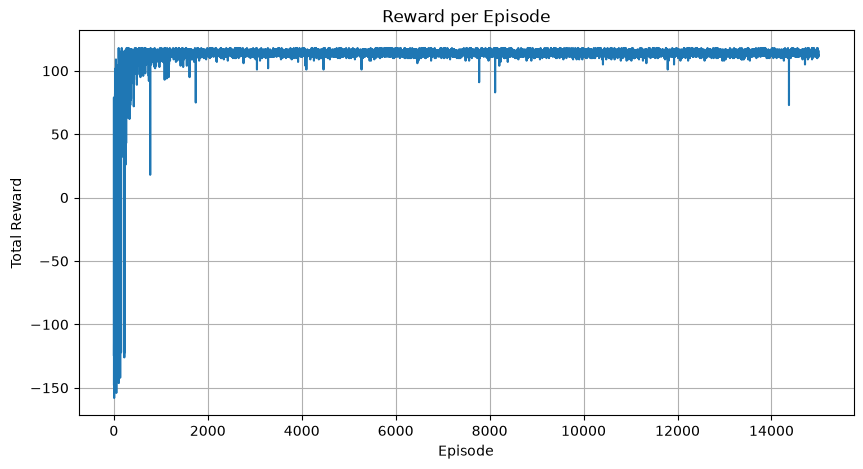

In [61]:
#Reward/Episode graph
visualize(
    states.ep_rewards,
    "Reward per Episode",
    "Episode",
    "Total Reward"
)

### 2. Average reward / Episode

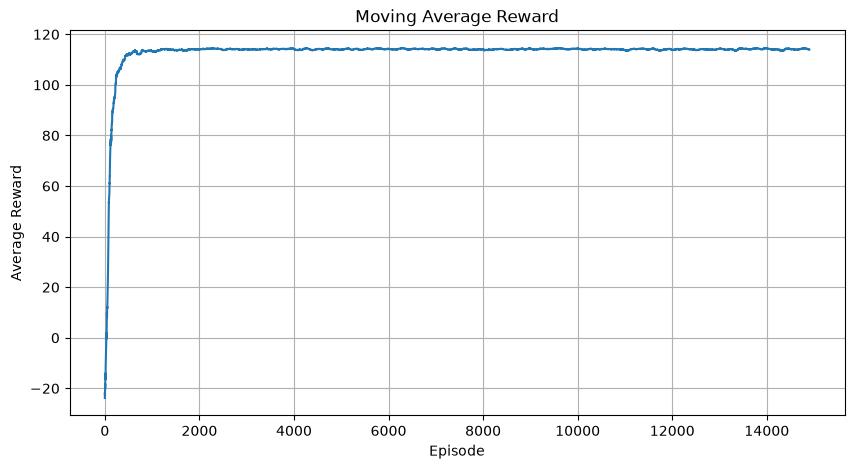

In [62]:
window = 100

moving_average = []

for i in range(len(states.ep_rewards) - window + 1):
    average = np.mean(states.ep_rewards[i:i + window])
    moving_average.append(average)

#Average reward/Episode graph
visualize(
    moving_average,
    "Moving Average Reward",
    "Episode",
    "Average Reward"
)

### 3. Steps / Episode

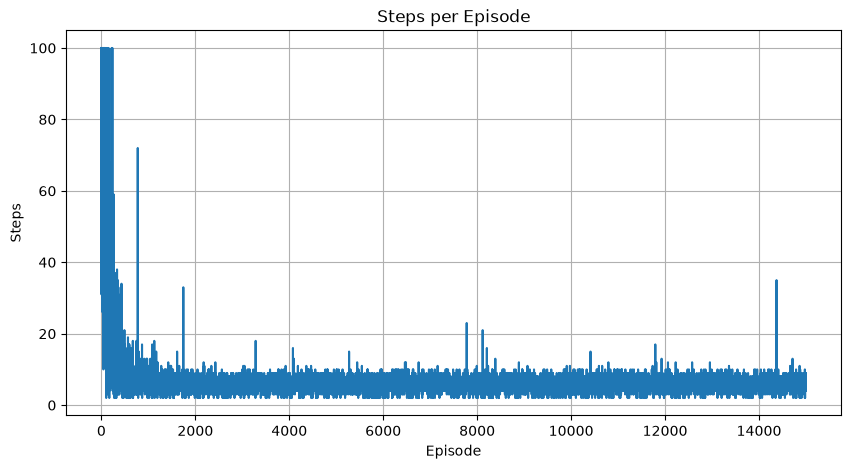

In [63]:
#Steps per episode graph
visualize(
    states.ep_steps,
    "Steps per Episode",
    "Episode",
    "Steps"
)

### 4. Success Rate

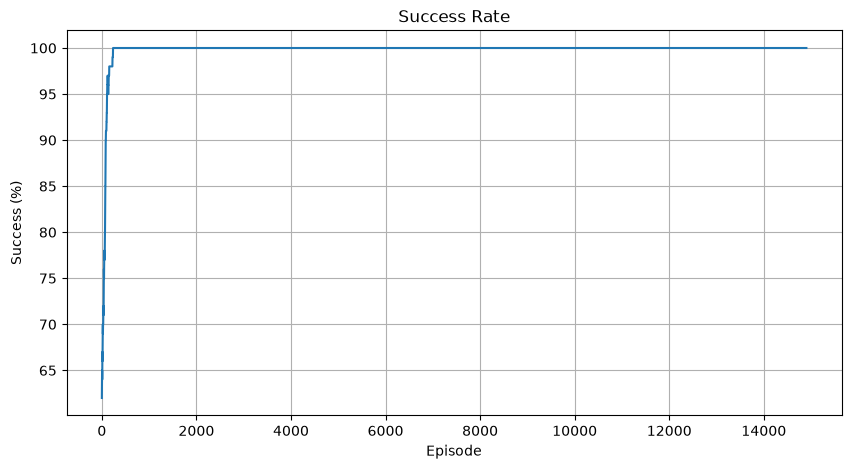

In [64]:
window = 100

success_rate = []

for i in range(len(states.ep_done) - window + 1):
    success_rate.append(
        np.mean(states.ep_done[i:i+window]) * 100
    )

#success rate graph
visualize(
    success_rate,
    "Success Rate",
    "Episode",
    "Success (%)"
)